In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import files
uploaded = files.upload()

Saving rainfall.csv to rainfall.csv


In [8]:
import pandas as pd
df = pd.read_csv("rainfall.csv")
print(df.head())

   index                SUBDIVISION  YEAR   JAN    FEB   MAR    APR    MAY  \
0      0  ANDAMAN & NICOBAR ISLANDS  1901  49.2   87.1  29.2    2.3  528.8   
1      1  ANDAMAN & NICOBAR ISLANDS  1902   0.0  159.8  12.2    0.0  446.1   
2      2  ANDAMAN & NICOBAR ISLANDS  1903  12.7  144.0   0.0    1.0  235.1   
3      3  ANDAMAN & NICOBAR ISLANDS  1904   9.4   14.7   0.0  202.4  304.5   
4      4  ANDAMAN & NICOBAR ISLANDS  1905   1.3    0.0   3.3   26.9  279.5   

     JUN    JUL    AUG    SEP    OCT    NOV    DEC  ANNUAL  Jan-Feb  Mar-May  \
0  517.5  365.1  481.1  332.6  388.5  558.2   33.6  3373.2    136.3    560.3   
1  537.1  228.9  753.7  666.2  197.2  359.0  160.5  3520.7    159.8    458.3   
2  479.9  728.4  326.7  339.0  181.2  284.4  225.0  2957.4    156.7    236.1   
3  495.1  502.0  160.1  820.4  222.2  308.7   40.1  3079.6     24.1    506.9   
4  628.7  368.7  330.5  297.0  260.7   25.4  344.7  2566.7      1.3    309.7   

   Jun-Sep  Oct-Dec  
0   1696.3    980.3  
1   21

In [10]:
df = pd.read_csv("rainfall.csv")
print(df.head())
print(df.shape)
print(df.columns)

   index                SUBDIVISION  YEAR   JAN    FEB   MAR    APR    MAY  \
0      0  ANDAMAN & NICOBAR ISLANDS  1901  49.2   87.1  29.2    2.3  528.8   
1      1  ANDAMAN & NICOBAR ISLANDS  1902   0.0  159.8  12.2    0.0  446.1   
2      2  ANDAMAN & NICOBAR ISLANDS  1903  12.7  144.0   0.0    1.0  235.1   
3      3  ANDAMAN & NICOBAR ISLANDS  1904   9.4   14.7   0.0  202.4  304.5   
4      4  ANDAMAN & NICOBAR ISLANDS  1905   1.3    0.0   3.3   26.9  279.5   

     JUN    JUL    AUG    SEP    OCT    NOV    DEC  ANNUAL  Jan-Feb  Mar-May  \
0  517.5  365.1  481.1  332.6  388.5  558.2   33.6  3373.2    136.3    560.3   
1  537.1  228.9  753.7  666.2  197.2  359.0  160.5  3520.7    159.8    458.3   
2  479.9  728.4  326.7  339.0  181.2  284.4  225.0  2957.4    156.7    236.1   
3  495.1  502.0  160.1  820.4  222.2  308.7   40.1  3079.6     24.1    506.9   
4  628.7  368.7  330.5  297.0  260.7   25.4  344.7  2566.7      1.3    309.7   

   Jun-Sep  Oct-Dec  
0   1696.3    980.3  
1   21

In [11]:
df = df.dropna()
df.columns = df.columns.str.strip()
print(df.isnull().sum())

index          0
SUBDIVISION    0
YEAR           0
JAN            0
FEB            0
MAR            0
APR            0
MAY            0
JUN            0
JUL            0
AUG            0
SEP            0
OCT            0
NOV            0
DEC            0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
dtype: int64


In [16]:
print(df.columns)
print(df.head())

Index(['index', 'SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY',
       'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb',
       'Mar-May', 'Jun-Sep', 'Oct-Dec'],
      dtype='object')
   index                SUBDIVISION  YEAR   JAN    FEB   MAR    APR    MAY  \
0      0  ANDAMAN & NICOBAR ISLANDS  1901  49.2   87.1  29.2    2.3  528.8   
1      1  ANDAMAN & NICOBAR ISLANDS  1902   0.0  159.8  12.2    0.0  446.1   
2      2  ANDAMAN & NICOBAR ISLANDS  1903  12.7  144.0   0.0    1.0  235.1   
3      3  ANDAMAN & NICOBAR ISLANDS  1904   9.4   14.7   0.0  202.4  304.5   
4      4  ANDAMAN & NICOBAR ISLANDS  1905   1.3    0.0   3.3   26.9  279.5   

     JUN    JUL    AUG    SEP    OCT    NOV    DEC  ANNUAL  Jan-Feb  Mar-May  \
0  517.5  365.1  481.1  332.6  388.5  558.2   33.6  3373.2    136.3    560.3   
1  537.1  228.9  753.7  666.2  197.2  359.0  160.5  3520.7    159.8    458.3   
2  479.9  728.4  326.7  339.0  181.2  284.4  225.0  2957.4    156.7    236.1 

In [17]:
X = df[['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN','JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']]
y = df['ANNUAL']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3272, 12)
Testing data: (818, 12)


In [19]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
n_estimators=100,
random_state=42
)
model.fit(X_train, y_train)
print("Model training completed successfully!")

Model training completed successfully!


In [20]:
y_pred = model.predict(X_test)
print("Predicted rainfall values:")
print(y_pred[:10])

Predicted rainfall values:
[1351.65  1191.925  488.077  928.556 2655.495 1176.332 1540.045 2403.462
 3239.066  950.867]


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 91.95341687041564
Mean Squared Error: 27314.29954846331
R2 Score: 0.9684442667717008


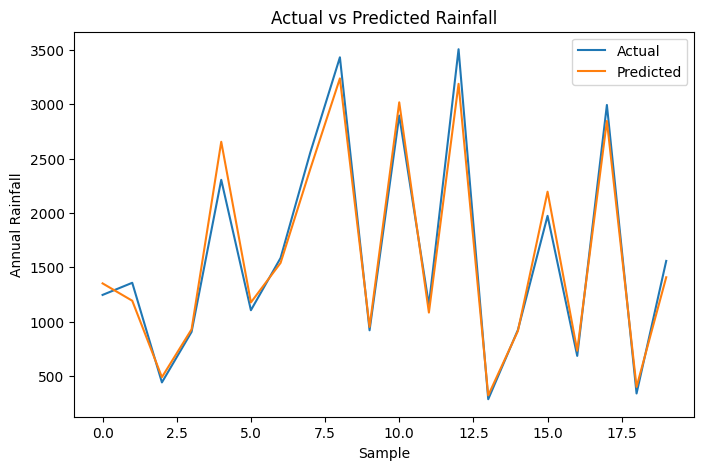

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(y_test.values[:20], label="Actual")
plt.plot(y_pred[:20], label="Predicted")
plt.xlabel("Sample")
plt.ylabel("Annual Rainfall")
plt.title("Actual vs Predicted Rainfall")
plt.legend()
plt.show()

In [23]:
import joblib
joblib.dump(model, "rainfall_model.pkl")
print("Model saved successfully!")

Model saved successfully!
